<a href="https://colab.research.google.com/github/hytt25/learning/blob/main/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import kagglehub
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

Using Colab cache for faster access to the 'bitcoin-historical-data' dataset.


In [9]:
import os
import pandas as pd

# 查看下载路径下的内容
print(f"Bitcoin 数据集路径: {path}")
files = os.listdir(path)
print("目录下的文件:", files)

# 查找 CSV 文件并读取
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"\n成功加载文件: {csv_files[0]}")
    print("数据集字段 (Columns):")
    print(df.columns.tolist())
    display(df.head())
else:
    print("未找到 CSV 文件。")

Bitcoin 数据集路径: /kaggle/input/bitcoin-historical-data
目录下的文件: ['btcusd_1-min_data.csv']

成功加载文件: btcusd_1-min_data.csv
数据集字段 (Columns):
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [15]:
!pip install shap

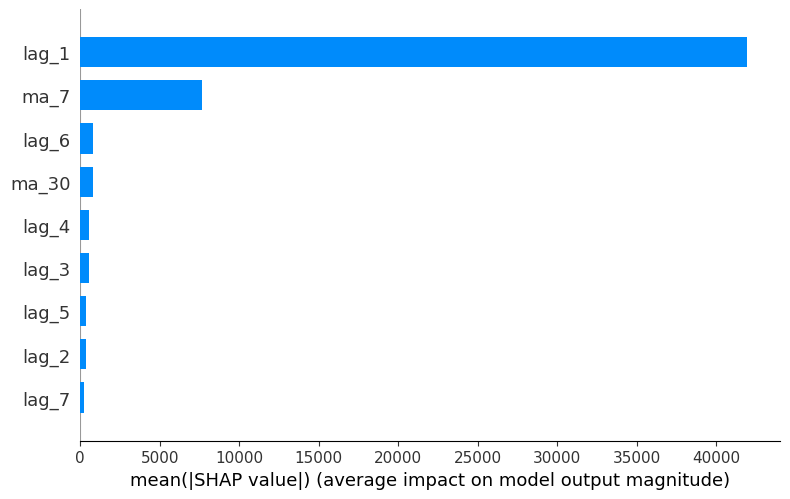

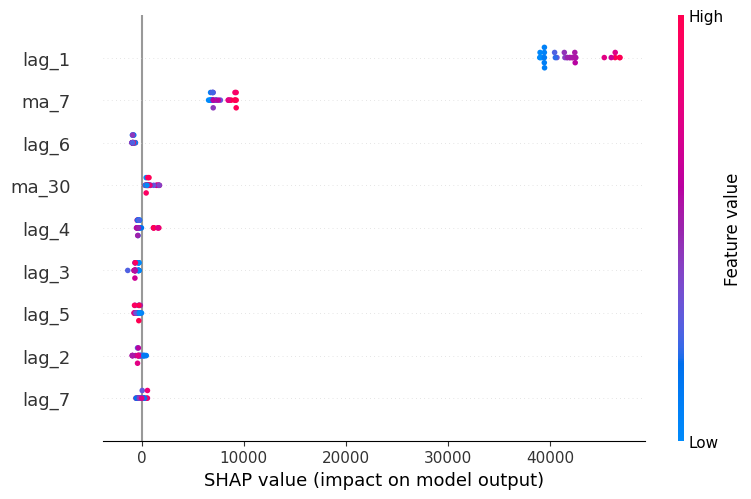

In [16]:
import shap

# 初始化 SHAP 解释器
explainer = shap.TreeExplainer(model_optimized)
# 计算测试集的 SHAP 值
shap_values = explainer.shap_values(X_test)

# 绘制 SHAP 汇总图
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 绘制更详细的散点图，观察特征值高低对预测的影响
shap.summary_plot(shap_values, X_test)

### SHAP 图表分析结论

通过上述图表，我们可以观察到：
1. **特征重要性（柱状图）**：它展示了哪些滞后项（lag）或移动平均线（ma）对模型预测价格的波动贡献最大。通常 `lag_1`（前一天价格）会有极高的权重。
2. **影响方向（散点图）**：红色代表特征值较高，蓝色代表较低。如果 `lag_1` 的红色点集中在右侧，说明前一天的价格越高，模型预测明天的价格也越高。

由于我们目前使用的是**日线级别**的重采样数据，图中的 `lag_1` 代表前 1 天（1440 分钟）的平均波动。如果需要更精细到“分钟”级的影响，我们需要重新以分钟为单位提取特征，但那会导致计算量巨大。目前的日线模型能告诉我们过去一周中哪一天的趋势最为关键。

优化后测试集 RMSE: 3213.39
原始模型 RMSE: 2265.96


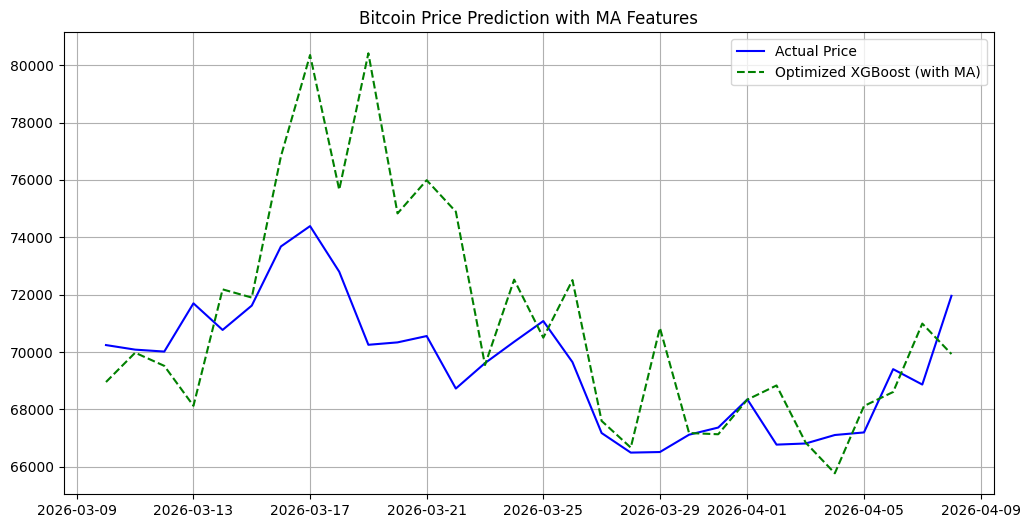

In [14]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 1. 重新准备基础数据
df_daily = df.set_index('date')['Close'].resample('D').mean().dropna().to_frame()

# 2. 加入移动平均线特征
df_daily['ma_7'] = df_daily['Close'].rolling(window=7).mean()
df_daily['ma_30'] = df_daily['Close'].rolling(window=30).mean()

# 3. 加入原有的滞后特征
for i in range(1, 8):
    df_daily[f'lag_{i}'] = df_daily['Close'].shift(i)

# 删除包含 NaN 的行（前30天由于 MA30 会产生空值）
df_daily = df_daily.dropna()

# 划分特征和标签
X = df_daily.drop(columns=['Close'])
y = df_daily['Close']

# 划分训练集和测试集
train_size = len(df_daily) - 30
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 4. 重新训练模型
model_optimized = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05)
model_optimized.fit(X_train, y_train)

# 预测与评估
predictions_opt = model_optimized.predict(X_test)
rmse_opt = np.sqrt(mean_squared_error(y_test, predictions_opt))

print(f"优化后测试集 RMSE: {rmse_opt:.2f}")
if 'rmse' in locals():
    print(f"原始模型 RMSE: {rmse:.2f}")

# 绘图对比
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index[train_size:], y_test, label='Actual Price', color='blue')
plt.plot(df_daily.index[train_size:], predictions_opt, label='Optimized XGBoost (with MA)', color='green', linestyle='--')
plt.title('Bitcoin Price Prediction with MA Features')
plt.legend()
plt.grid(True)
plt.show()

未来 7 天预测价格 (USD):


,Date,Predicted_Price
0,2026-04-09,70859.992188
1,2026-04-10,69047.015625
2,2026-04-11,68937.078125
3,2026-04-12,69783.195312
4,2026-04-13,68239.085938
5,2026-04-14,66453.484375
6,2026-04-15,66422.773438


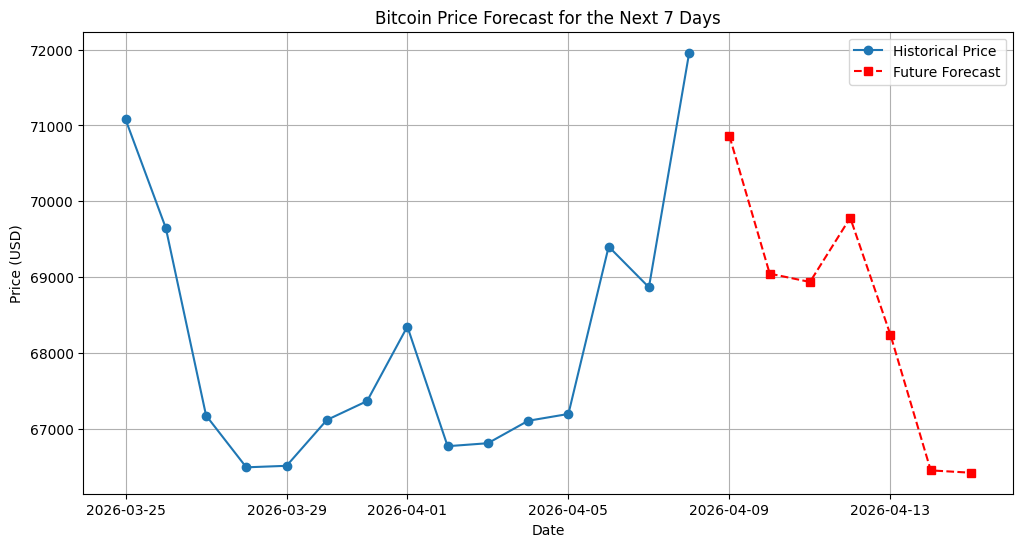

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 获取数据集中最后已知的 7 天数据作为初始输入
last_7_days = df_daily['Close'].iloc[-7:].values.tolist()
future_predictions = []
future_dates = pd.date_range(start=df_daily.index[-1] + pd.Timedelta(days=1), periods=7)

# 递归预测未来 7 天
current_batch = last_7_days.copy()

for i in range(7):
    # 构造特征 (lag_1, lag_2, ..., lag_7)
    # 注意：我们的模型训练时特征顺序是 lag_1 (前1天), lag_2 (前2天)...
    # current_batch 存储顺序为 [oldest, ..., newest], 所以需要反转
    X_input = np.array(current_batch[::-1]).reshape(1, -1)

    # 预测
    pred = model.predict(X_input)[0]
    future_predictions.append(pred)

    # 更新 batch：移除最旧的，加入最新的预测值
    current_batch.pop(0)
    current_batch.append(pred)

# 创建展示结果的 DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Price': future_predictions
})

print("未来 7 天预测价格 (USD):")
display(future_df)

# 绘图展示：历史最后 15 天 + 未来 7 天
plt.figure(figsize=(12, 6))
hist_days = 15
plt.plot(df_daily.index[-hist_days:], df_daily['Close'].iloc[-hist_days:], label='Historical Price', marker='o')
plt.plot(future_df['Date'], future_df['Predicted_Price'], label='Future Forecast', color='red', linestyle='--', marker='s')

plt.title('Bitcoin Price Forecast for the Next 7 Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 数据重采样：按天计算平均收盘价
df_daily = df.set_index('date')['Close'].resample('D').mean().dropna().to_frame()

# 2. 特征工程：创建过去7天的滞后特征
for i in range(1, 8):
    df_daily[f'lag_{i}'] = df_daily['Close'].shift(i)

# 删除包含 NaN 的行（前7天）
df_daily = df_daily.dropna()

# 划分特征和标签
X = df_daily.drop(columns=['Close'])
y = df_daily['Close']

# 划分训练集和测试集 (最近 30 天作为测试)
train_size = len(df_daily) - 30
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"训练集样本数: {len(X_train)}, 测试集样本数: {len(X_test)}")

训练集样本数: 5175, 测试集样本数: 30


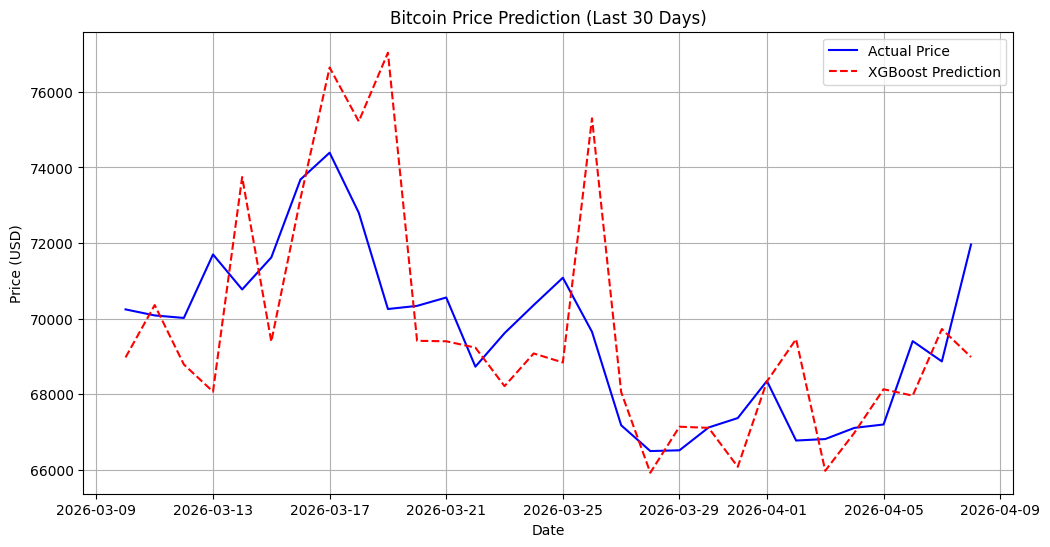

测试集 RMSE: 2265.96


In [12]:
# 3. 训练 XGBoost 模型
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05)
model.fit(X_train, y_train)

# 预测
predictions = model.predict(X_test)

# 绘图对比
plt.figure(figsize=(12, 6))
plt.plot(df_daily.index[train_size:], y_test, label='Actual Price', color='blue')
plt.plot(df_daily.index[train_size:], predictions, label='XGBoost Prediction', color='red', linestyle='--')
plt.title('Bitcoin Price Prediction (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"测试集 RMSE: {rmse:.2f}")

/tmp/ipykernel_8774/4062663172.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


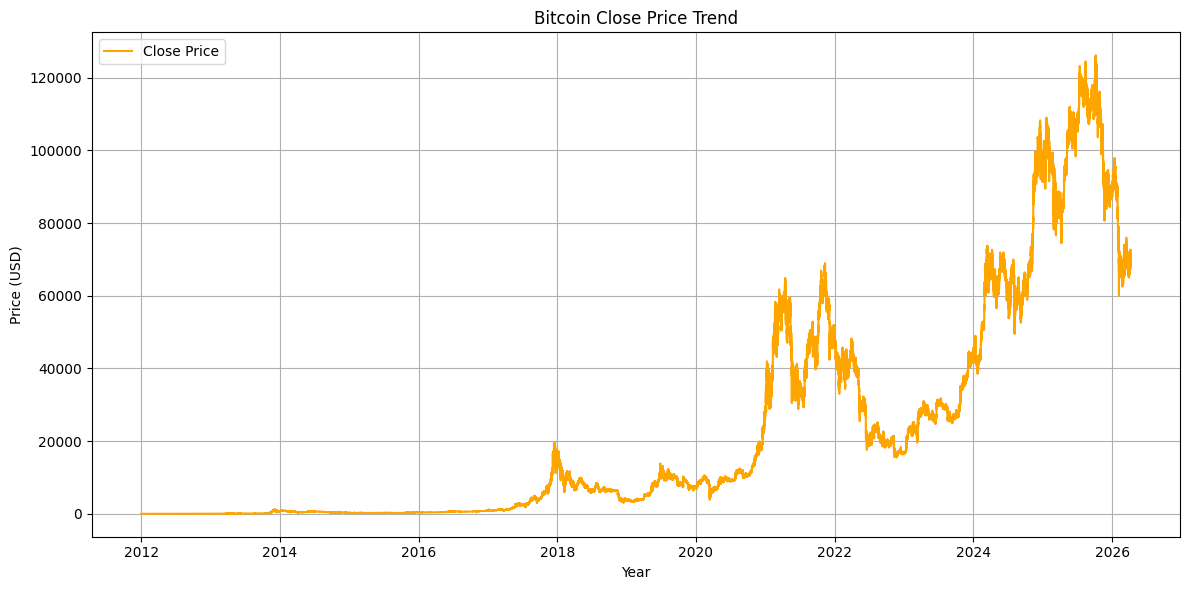

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 转换时间戳为日期格式
# 注意：如果数据量非常大，绘制每一分钟可能会很慢，这里先处理时间格式
df['date'] = pd.to_datetime(df['Timestamp'], unit='s')

# 绘制趋势图
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['Close'], color='orange', label='Close Price')

plt.title('Bitcoin Close Price Trend')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()